In [1]:
from matplotlib import pyplot as plt
from itertools import product
import seaborn as sns
import pandas as pd
import os.path as op
import argparse
import re
import numpy as np
import matplotlib.pyplot as plt
import mne
from scipy import signal, stats
from scipy.fft import fftshift
from bids import BIDSLayout
from statsmodels.stats.anova import AnovaRM
from util.io.ffr import *

In [2]:
spectrums = pd.read_csv('spectrums.csv', sep = '\t')

In [8]:
palette_tab10 = sns.color_palette("tab10", 10)

### FFR by Performance Group

In [3]:
# Add performance group to dataframe
performance_groups = pd.read_csv('task-performance-groups.csv')
performance_groups = performance_groups.rename(columns = {'sub_num': 'subject'})
spectrums = spectrums.merge(performance_groups, left_on = ["subject"], right_on = ["subject"])
spectrums

,subject,passive,target,tone,frequency,dB,group
0,2,False,130.0,130,0.000000,3.198267,decliner
1,2,False,130.0,130,4.995005,3.067914,decliner
2,2,False,130.0,130,9.990010,3.006004,decliner
3,2,False,130.0,130,14.985015,3.149232,decliner
4,2,False,130.0,130,19.980020,2.993786,decliner
...,...,...,...,...,...,...,...
156307,30,True,NaN,280,2477.522478,6.687229,decliner
156308,30,True,NaN,280,2482.517483,6.687544,decliner
156309,30,True,NaN,280,2487.512488,6.686134,decliner
156310,30,True,NaN,280,2492.507493,6.685909,decliner


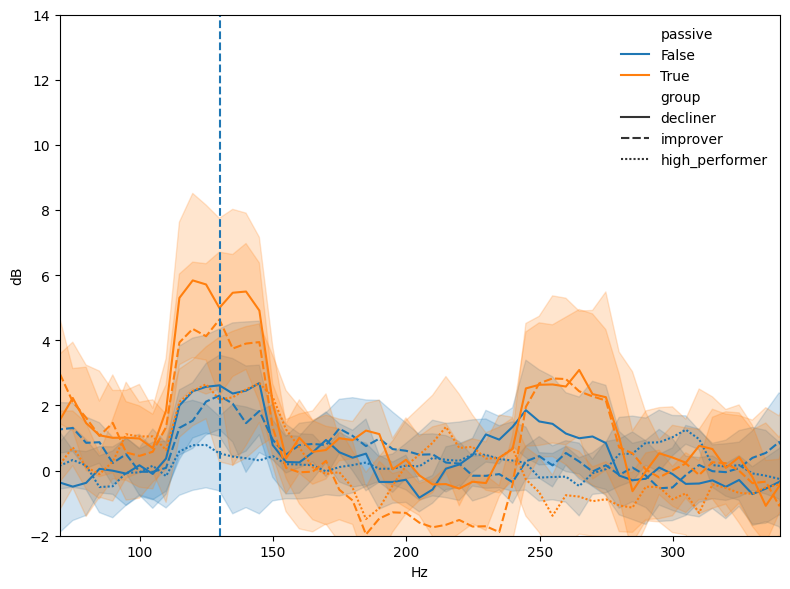

In [28]:
spectrums_130 = spectrums[spectrums.tone == 130]
fig, ax = plt.subplots(figsize=(8, 6))
spectrums_accuracy = spectrums_130.groupby(['subject', 'frequency', 'passive', 'group'], as_index=False)['dB'].mean()
graph = sns.lineplot(data = spectrums_accuracy, x = "frequency", y = "dB", hue = "passive", style = "group", palette = 'tab10', ax = ax, style_order = ['decliner', 'improver', 'high_performer'])
graph.axvline(130, linestyle = 'dashed', color = palette_tab10[0])
graph.set_ylabel("dB")
graph.set_xlabel("Hz")
graph.set_xlim(70, 340)
graph.set_ylim(-2, 14)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('../figs/FFR-tone-1-by-performance-group.png', dpi = 300)

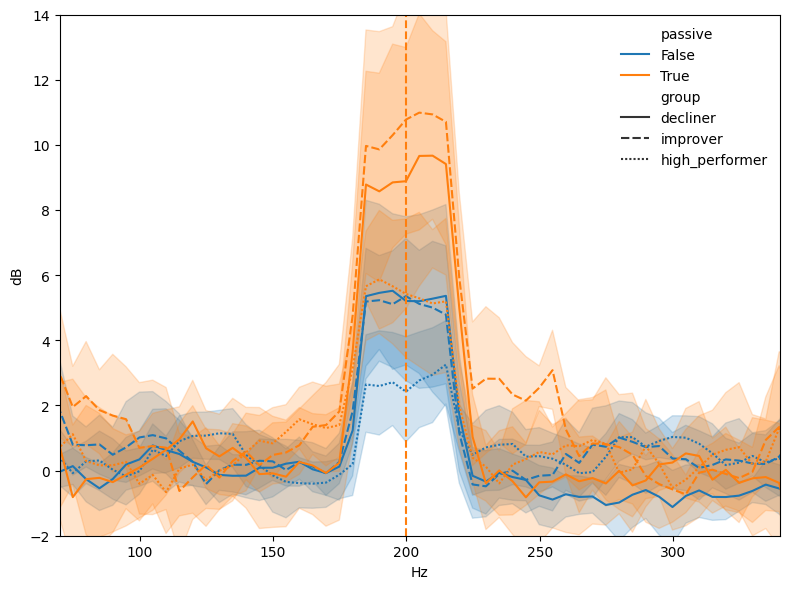

In [29]:
spectrums_200 = spectrums[spectrums.tone == 200]
fig, ax = plt.subplots(figsize=(8, 6))
spectrums_accuracy = spectrums_200.groupby(['subject', 'frequency', 'passive', 'group'], as_index=False)['dB'].mean()
graph = sns.lineplot(data = spectrums_accuracy, x = "frequency", y = "dB", hue = "passive", style = "group", palette = 'tab10', ax = ax, style_order = ['decliner', 'improver', 'high_performer'])
graph.axvline(200, linestyle = 'dashed', color = palette_tab10[1])
graph.set_ylabel("dB")
graph.set_xlabel("Hz")
graph.set_xlim(70, 340)
graph.set_ylim(-2, 14)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('../figs/FFR-tone-2-by-performance-group.png', dpi = 300)

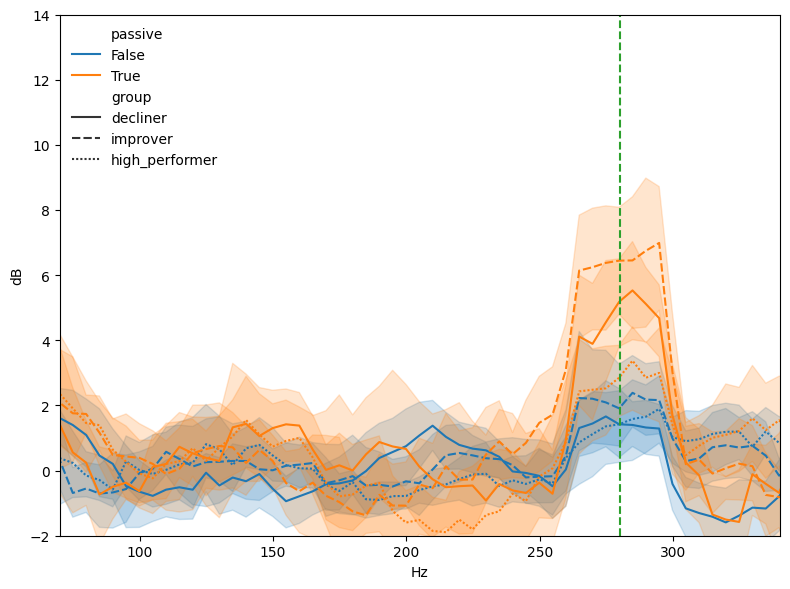

In [30]:
spectrums_280 = spectrums[spectrums.tone == 280]
fig, ax = plt.subplots(figsize=(8, 6))
spectrums_accuracy = spectrums_280.groupby(['subject', 'frequency', 'passive', 'group'], as_index=False)['dB'].mean()
graph = sns.lineplot(data = spectrums_accuracy, x = "frequency", y = "dB", hue = "passive", style = "group", palette = 'tab10', ax = ax, style_order = ['decliner', 'improver', 'high_performer'])
graph.axvline(280, linestyle = 'dashed', color = palette_tab10[2])
graph.set_ylabel("dB")
graph.set_xlabel("Hz")
graph.set_xlim(70, 340)
graph.set_ylim(-2, 14)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('../figs/FFR-tone-3-by-performance-group.png', dpi = 300)

## Interaction between passive and group and block order

In [16]:
spectrums = pd.read_csv('spectrums.csv', sep = '\t')

# Add passive order
passive = pd.read_csv('../data/condition-order.csv')
passive = passive.rename(columns = {'passive': 'passive_order'})
spectrums = spectrums.merge(passive, left_on = ["subject"], right_on = ["sub_num"])

# Add performance group to dataframe
performance_groups = pd.read_csv('task-performance-groups.csv')
performance_groups = performance_groups.rename(columns = {'sub_num': 'subject'})
spectrums = spectrums.merge(performance_groups, left_on = ["subject"], right_on = ["subject"])
spectrums = spectrums.sort_values(by='group')
spectrums

,subject,passive,target,tone,frequency,dB,sub_num,passive_order,group
0,2,False,130.0,130,0.000000,3.198267,2,1,decliner
74151,15,False,200.0,200,14.985015,6.720393,15,1,decliner
74150,15,False,200.0,200,9.990010,8.915519,15,1,decliner
74149,15,False,200.0,200,4.995005,13.461029,15,1,decliner
74148,15,False,200.0,200,0.000000,12.333698,15,1,decliner
...,...,...,...,...,...,...,...,...,...
116236,23,False,200.0,200,19.980020,-3.301760,23,1,improver
116237,23,False,200.0,200,24.975025,-1.699530,23,1,improver
116238,23,False,200.0,200,29.970030,-2.033865,23,1,improver
116226,23,False,200.0,130,2472.527473,-5.974705,23,1,improver


### Subjects who received the passive block first

In [17]:
spectrums_passive_first = spectrums[spectrums.passive_order == 1]

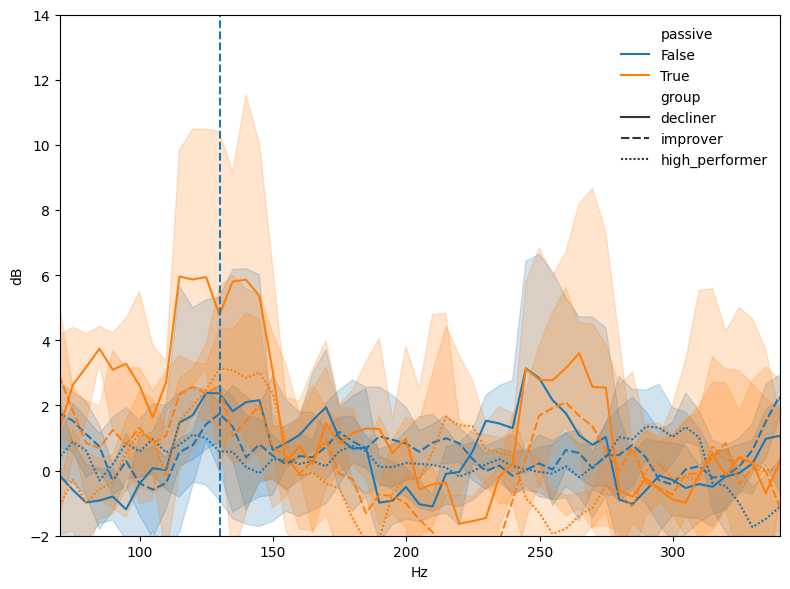

In [26]:
spectrums_130 = spectrums_passive_first[spectrums_passive_first.tone == 130]
fig, ax = plt.subplots(figsize=(8, 6))
spectrums_accuracy = spectrums_130.groupby(['subject', 'frequency', 'passive', 'group'], as_index=False)['dB'].mean()
graph = sns.lineplot(data = spectrums_accuracy, x = "frequency", y = "dB", hue = "passive", style = "group", palette = 'tab10', ax = ax, style_order = ['decliner', 'improver', 'high_performer'])
graph.axvline(130, linestyle = 'dashed', color = palette_tab10[0])
graph.set_ylabel("dB")
graph.set_xlabel("Hz")
graph.set_xlim(70, 340)
graph.set_ylim(-2, 14)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('../figs/FFR-tone-1-by-performance-group-passive-first.png', dpi = 300)

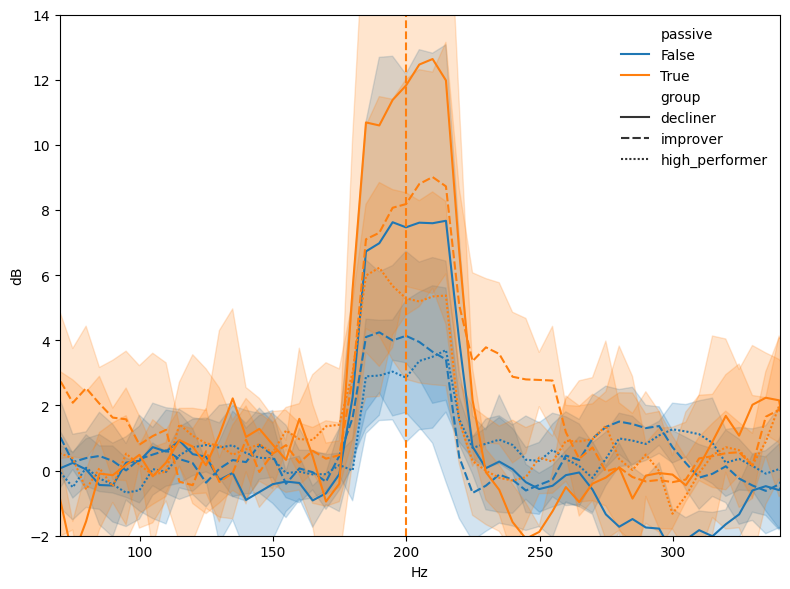

In [10]:
spectrums_200 = spectrums_passive_first[spectrums_passive_first.tone == 200]
fig, ax = plt.subplots(figsize=(8, 6))
spectrums_accuracy = spectrums_200.groupby(['subject', 'frequency', 'passive', 'group'], as_index=False)['dB'].mean()
graph = sns.lineplot(data = spectrums_accuracy, x = "frequency", y = "dB", hue = "passive", style = "group", palette = 'tab10', ax = ax, style_order = ['decliner', 'improver', 'high_performer'])
graph.axvline(200, linestyle = 'dashed', color = palette_tab10[1])
graph.set_ylabel("dB")
graph.set_xlabel("Hz")
graph.set_xlim(70, 340)
graph.set_ylim(-2, 14)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('../figs/FFR-tone-2-by-performance-group-passive-first.png', dpi = 300)

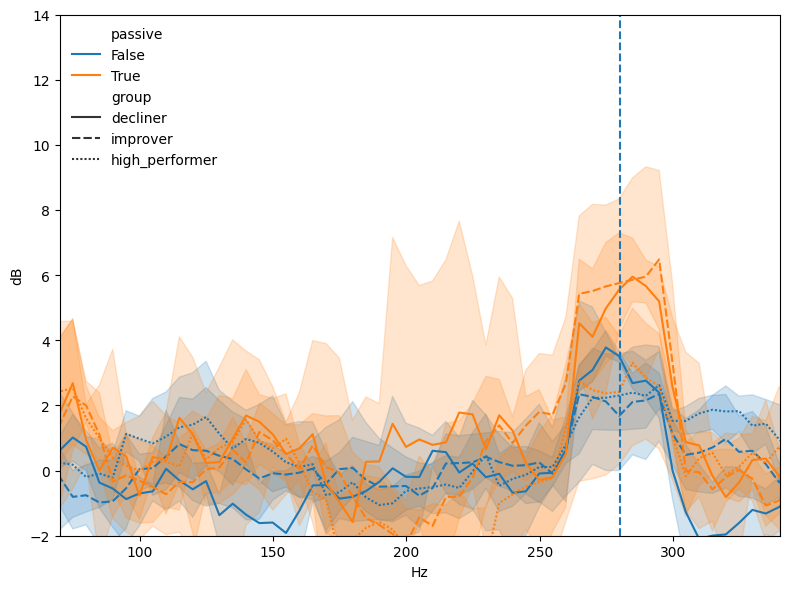

In [11]:
spectrums_280 = spectrums_passive_first[spectrums_passive_first.tone == 280]
fig, ax = plt.subplots(figsize=(8, 6))
spectrums_accuracy = spectrums_280.groupby(['subject', 'frequency', 'passive', 'group'], as_index=False)['dB'].mean()
graph = sns.lineplot(data = spectrums_accuracy, x = "frequency", y = "dB", hue = "passive", style = "group", palette = 'tab10', ax = ax, style_order = ['decliner', 'improver', 'high_performer'])
graph.axvline(280, linestyle = 'dashed', color = palette_tab10[0])
graph.set_ylabel("dB")
graph.set_xlabel("Hz")
graph.set_xlim(70, 340)
graph.set_ylim(-2, 14)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('../figs/FFR-tone-3-by-performance-group-passive-first.png', dpi = 300)

### Passive block second

In [12]:
spectrums_passive_second = spectrums[spectrums.passive_order == 2]

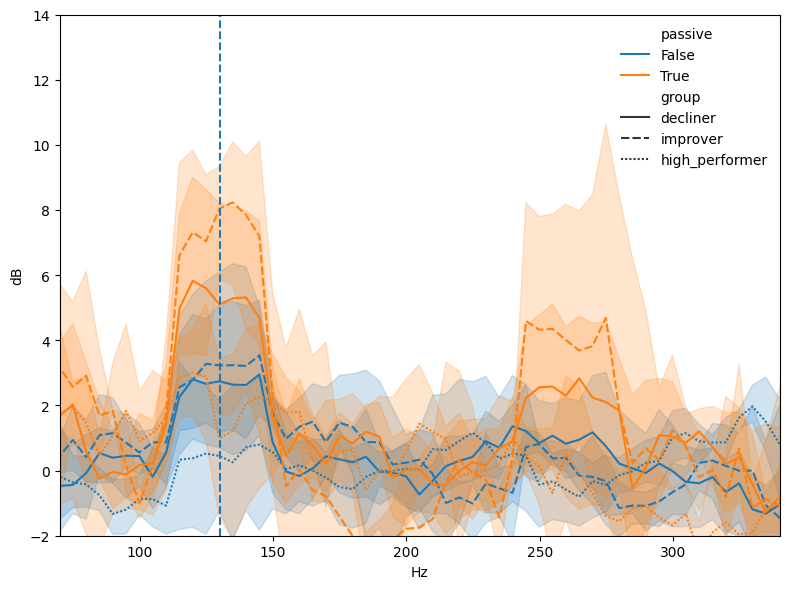

In [27]:
spectrums_130 = spectrums_passive_second[spectrums_passive_second.tone == 130]
fig, ax = plt.subplots(figsize=(8, 6))
spectrums_accuracy = spectrums_130.groupby(['subject', 'frequency', 'passive', 'group'], as_index=False)['dB'].mean()
graph = sns.lineplot(data = spectrums_accuracy, x = "frequency", y = "dB", hue = "passive", style = "group", palette = 'tab10', ax = ax, style_order = ['decliner', 'improver', 'high_performer'])
graph.axvline(130, linestyle = 'dashed', color = palette_tab10[0])
graph.set_ylabel("dB")
graph.set_xlabel("Hz")
graph.set_xlim(70, 340)
graph.set_ylim(-2, 14)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('../figs/FFR-tone-1-by-performance-group-passive-second.png', dpi = 300)

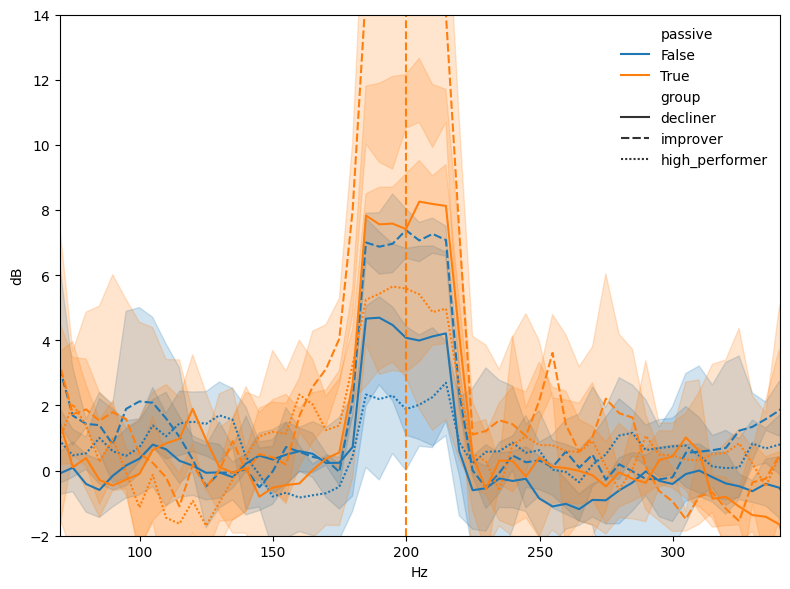

In [23]:
spectrums_200 = spectrums_passive_second[spectrums_passive_second.tone == 200]
fig, ax = plt.subplots(figsize=(8, 6))
spectrums_accuracy = spectrums_200.groupby(['subject', 'frequency', 'passive', 'group'], as_index=False)['dB'].mean()
graph = sns.lineplot(data = spectrums_accuracy, x = "frequency", y = "dB", hue = "passive", style = "group", palette = 'tab10', ax = ax, style_order = ['decliner', 'improver', 'high_performer'])
graph.axvline(200, linestyle = 'dashed', color = palette_tab10[1])
graph.set_ylabel("dB")
graph.set_xlabel("Hz")
graph.set_xlim(70, 340)
graph.set_ylim(-2, 14)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('../figs/FFR-tone-2-by-performance-group-passive-second.png', dpi = 300)

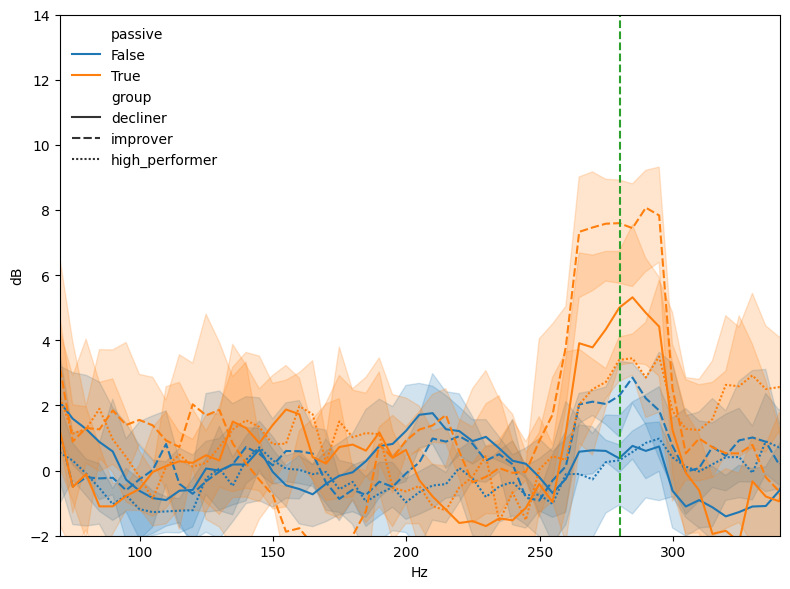

In [24]:
spectrums_280 = spectrums_passive_second[spectrums_passive_second.tone == 280]
fig, ax = plt.subplots(figsize=(8, 6))
spectrums_accuracy = spectrums_280.groupby(['subject', 'frequency', 'passive', 'group'], as_index=False)['dB'].mean()
graph = sns.lineplot(data = spectrums_accuracy, x = "frequency", y = "dB", hue = "passive", style = "group", palette = 'tab10', ax = ax, style_order = ['decliner', 'improver', 'high_performer'])
graph.axvline(280, linestyle = 'dashed', color = palette_tab10[2])
graph.set_ylabel("dB")
graph.set_xlabel("Hz")
graph.set_xlim(70, 340)
graph.set_ylim(-2, 14)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('../figs/FFR-tone-3-by-performance-group-passive-second.png', dpi = 300)